# Phase 1 — Part 4: Feature Engineering
**Author:** Markela  

## 4.1 Motivation

Raw tabular data from electronic health records only weakly expresses the non-linear risk structure that clinicians rely on when reasoning about stroke. Epidemiological studies consistently report that age, hypertension, diabetes, obesity and smoking interact in multiplicative rather than additive ways, and that risk thresholds (for example, the ADA glycaemic cut-off of 126 mg/dL or the WHO obesity class boundaries at 30, 35, and 40 kg/m²) are clinically meaningful rather than arbitrary. A linear classifier trained on the raw variables cannot recover these regime changes; a tree ensemble can in principle approximate them but only at the cost of sample efficiency and interpretability.

Feature engineering closes this gap by explicitly injecting clinical prior knowledge into the representation. Well-designed engineered features serve three purposes simultaneously. First, they enable simple, interpretable models (logistic regression, linear SVM) to capture non-linearities and interactions that would otherwise require a much larger hypothesis class. Second, they improve interpretability of any downstream model, because features such as ``comorbidity_count`` or ``is_metabolic_risk`` speak the same language as the clinical literature. Third, they produce compact, statistically validated signal that can be ranked against the target using mutual information and chi-squared tests, allowing us to triage which hand-crafted features genuinely carry information and which merely restate the raw columns.

In this notebook we (i) design a battery of clinically motivated features, (ii) validate each of them against the ``stroke`` target with non-parametric statistics, (iii) inspect redundancy via correlation analysis, and (iv) persist a final enriched dataset that downstream phases will consume.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
DATA_PATH = PROJECT_ROOT / "data" / "healthcare-dataset-stroke-data.csv"
FIGURES_DIR = PROJECT_ROOT / "figures"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data path : {DATA_PATH}")
print(f"Figures   : {FIGURES_DIR}")
print(f"Outputs   : {OUTPUTS_DIR}")

Data path : C:\Users\donat\Desktop\Markie\data\healthcare-dataset-stroke-data.csv
Figures   : C:\Users\donat\Desktop\Markie\figures
Outputs   : C:\Users\donat\Desktop\Markie\outputs


In [2]:
df = pd.read_csv(DATA_PATH)

# 'N/A' strings in bmi become real NaN; cast to numeric.
df["bmi"] = pd.to_numeric(df["bmi"], errors="coerce")

# Remove the single gender == 'Other' observation (degenerate stratum).
df = df[df["gender"] != "Other"].copy()

# Drop the surrogate identifier; it carries no predictive signal.
if "id" in df.columns:
    df = df.drop(columns=["id"])

df = df.reset_index(drop=True)
print(f"Shape after cleaning : {df.shape}")
print(f"Missing BMI rows     : {df['bmi'].isna().sum()}")
print(f"Positive stroke rate : {df['stroke'].mean():.4f}")
df.head()

Shape after cleaning : (5109, 11)
Missing BMI rows     : 201
Positive stroke rate : 0.0487


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 4.2 Clinical Feature Design

We group the engineered features into four families:

1. **Clinical discretisations.** ``age_group`` uses age strata that align with cardiovascular risk calculators (``<30``, ``30-45``, ``45-60``, ``60-75``, ``75+``). ``bmi_category`` follows the WHO classification (underweight, normal, overweight, obese I, obese II, obese III). ``glucose_category`` follows the ADA fasting glucose thresholds (normal ``<100``, prediabetic ``100-125``, diabetic ``≥126``).
2. **Aggregate risk burdens.** ``comorbidity_count`` adds hypertension and heart disease into a single 0/1/2 variable; ``smoking_risk`` maps the ordinal smoking status into a numeric scale with ``Unknown`` placed at the midpoint as an uninformative prior.
3. **Binary risk flags.** ``is_metabolic_risk`` fires when glucose ≥126 or BMI ≥30, mirroring the metabolic syndrome screening heuristic. ``is_high_risk_demographic`` fires for adults older than 60 with any cardiovascular comorbidity.
4. **Interaction and transform terms.** ``age_glucose`` and ``bmi_age`` expose multiplicative risk to linear models; ``log_glucose`` stabilises the right-skewed glucose distribution; ``age_squared`` introduces curvature in age.

In [3]:
AGE_BINS = [0, 30, 45, 60, 75, 120]
AGE_LABELS = ["<30", "30-45", "45-60", "60-75", "75+"]

BMI_BINS = [0, 18.5, 25, 30, 35, 40, np.inf]
BMI_LABELS = [
    "underweight",
    "normal",
    "overweight",
    "obese_I",
    "obese_II",
    "obese_III",
]

GLUCOSE_BINS = [0, 100, 126, np.inf]
GLUCOSE_LABELS = ["normal", "prediabetic", "diabetic"]

SMOKING_RISK_MAP = {
    "never smoked": 0.0,
    "Unknown": 0.5,
    "formerly smoked": 1.0,
    "smokes": 2.0,
}


def add_clinical_features(df: pd.DataFrame) -> pd.DataFrame:
    """Return a copy of *df* enriched with clinically informed features.

    Missing BMI is preserved as NaN in ``bmi_category`` and in every
    interaction term that involves BMI, so that downstream imputers can
    decide how to handle it.
    """
    out = df.copy()

    out["age_group"] = pd.cut(
        out["age"],
        bins=AGE_BINS,
        labels=AGE_LABELS,
        right=False,
        include_lowest=True,
    )

    out["bmi_category"] = pd.cut(
        out["bmi"],
        bins=BMI_BINS,
        labels=BMI_LABELS,
        right=False,
        include_lowest=True,
    )

    out["glucose_category"] = pd.cut(
        out["avg_glucose_level"],
        bins=GLUCOSE_BINS,
        labels=GLUCOSE_LABELS,
        right=False,
        include_lowest=True,
    )

    out["comorbidity_count"] = (
        out["hypertension"].astype(int) + out["heart_disease"].astype(int)
    )

    out["smoking_risk"] = out["smoking_status"].map(SMOKING_RISK_MAP).astype(float)

    out["is_metabolic_risk"] = (
        (out["avg_glucose_level"] >= 126) | (out["bmi"] >= 30)
    ).astype(int)

    out["is_high_risk_demographic"] = (
        (out["age"] > 60)
        & ((out["hypertension"] == 1) | (out["heart_disease"] == 1))
    ).astype(int)

    out["age_glucose"] = out["age"] * out["avg_glucose_level"]
    out["bmi_age"] = out["bmi"] * out["age"]
    out["log_glucose"] = np.log1p(out["avg_glucose_level"])
    out["age_squared"] = out["age"] ** 2

    return out


df_eng = add_clinical_features(df)
print("Enriched shape :", df_eng.shape)
print("\nAll columns:")
print(list(df_eng.columns))
df_eng.head()

Enriched shape : (5109, 22)

All columns:
['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke', 'age_group', 'bmi_category', 'glucose_category', 'comorbidity_count', 'smoking_risk', 'is_metabolic_risk', 'is_high_risk_demographic', 'age_glucose', 'bmi_age', 'log_glucose', 'age_squared']


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,...,bmi_category,glucose_category,comorbidity_count,smoking_risk,is_metabolic_risk,is_high_risk_demographic,age_glucose,bmi_age,log_glucose,age_squared
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,...,obese_II,diabetic,1,1.0,1,1,15322.23,2452.2,5.436731,4489.0
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,...,NaN,diabetic,0,0.0,1,0,12334.81,NaN,5.314240,3721.0
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,...,obese_I,prediabetic,1,0.0,1,1,8473.60,2600.0,4.672081,6400.0
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,...,obese_I,diabetic,0,2.0,1,0,8390.27,1685.6,5.148831,2401.0
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,...,normal,diabetic,1,0.0,1,1,13755.48,1896.0,5.165471,6241.0


## 4.3 Validating Engineered Features vs. Target

A feature is only useful if its within-level stroke rate departs from the global base rate of approximately 4.9 %. We therefore compute the empirical stroke rate for each level of the four categorical engineered variables and visualise the result as bar plots. A monotone trend in ``age_group`` and ``comorbidity_count`` is the signature we expect from the literature.


--- stroke rate by age_group ---
age_group    n  strokes  stroke_rate
      <30 1514        2     0.001321
    30-45 1018        8     0.007859
    45-60 1201       58     0.048293
    60-75  858       79     0.092075
      75+  518      102     0.196911

--- stroke rate by bmi_category ---
bmi_category    n  strokes  stroke_rate
 underweight  337        1     0.002967
      normal 1242       35     0.028180
  overweight 1409       75     0.053229
     obese_I 1000       56     0.056000
    obese_II  506       23     0.045455
   obese_III  414       19     0.045894

--- stroke rate by glucose_category ---
glucose_category    n  strokes  stroke_rate
          normal 3131      112     0.035771
     prediabetic  998       37     0.037074
        diabetic  980      100     0.102041

--- stroke rate by comorbidity_count ---
 comorbidity_count    n  strokes  stroke_rate
                 0 4399      149     0.033871
                 1  646       87     0.134675
                 2   64       

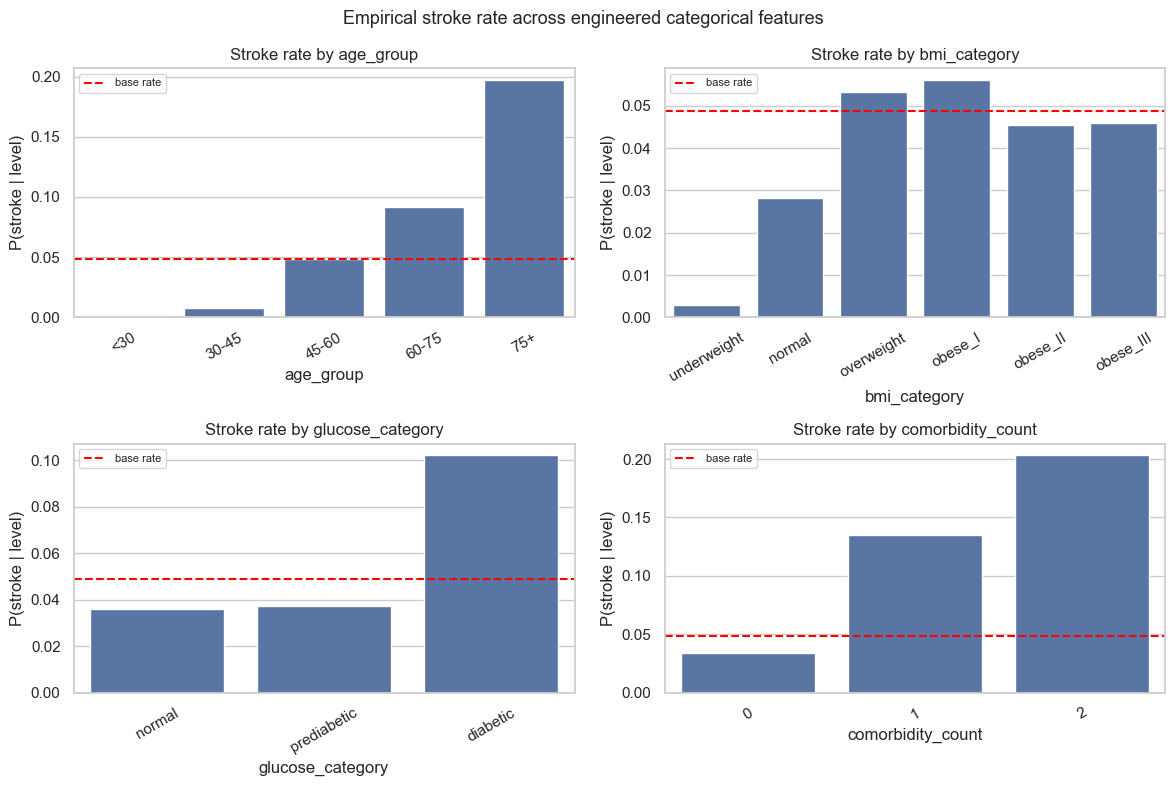

In [4]:
def stroke_rate_table(data: pd.DataFrame, column: str) -> pd.DataFrame:
    grp = (
        data.groupby(column, observed=False)["stroke"]
        .agg(n="size", strokes="sum", stroke_rate="mean")
        .reset_index()
    )
    return grp


tables = {}
for col in ["age_group", "bmi_category", "glucose_category", "comorbidity_count"]:
    t = stroke_rate_table(df_eng, col)
    tables[col] = t
    print(f"\n--- stroke rate by {col} ---")
    print(t.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (col, t) in zip(axes.ravel(), tables.items()):
    sns.barplot(data=t, x=col, y="stroke_rate", ax=ax, color="#4C72B0")
    ax.axhline(df_eng["stroke"].mean(), ls="--", color="red", label="base rate")
    ax.set_title(f"Stroke rate by {col}")
    ax.set_ylabel("P(stroke | level)")
    ax.set_xlabel(col)
    ax.tick_params(axis="x", rotation=30)
    ax.legend(loc="upper left", fontsize=8)

fig.suptitle("Empirical stroke rate across engineered categorical features", fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_engineered_stroke_rates.png", dpi=150, bbox_inches="tight")
plt.show()

## 4.4 Statistical Relevance: Chi-Squared and Mutual Information

We quantify the relevance of every feature (raw and engineered) against the binary target using two complementary, non-parametric criteria. The **chi-squared test** evaluates the null hypothesis that a categorical feature is independent of the target, and it is only defined for non-negative discrete inputs. **Mutual information** measures any statistical dependence, linear or not, between a feature and the target, and is well defined for both discrete and continuous inputs. Using the two in tandem lets us cross-validate importance rankings and detect features that are linearly trivial but informationally rich (for example, ``age_squared`` relative to ``age``).

                 feature          chi2  chi2_pvalue  mutual_information
                     age   3143.046472 0.000000e+00            0.035234
             age_squared 532186.114481 0.000000e+00            0.032594
               age_group      0.098291 7.538898e-01            0.031621
                 bmi_age  92660.649819 0.000000e+00            0.028624
             age_glucose 917292.688412 0.000000e+00            0.024080
       comorbidity_count    175.397430 4.902514e-40            0.014451
is_high_risk_demographic    192.182267 1.061703e-43            0.012728
               work_type      3.077614 7.937691e-02            0.012408
            ever_married     18.804795 1.448026e-05            0.006964
       is_metabolic_risk     11.351304 7.539502e-04            0.006348
        glucose_category     17.886335 2.344988e-05            0.006286
          smoking_status     10.798855 1.015629e-03            0.006009
           heart_disease     88.749305 4.481549e-21            0

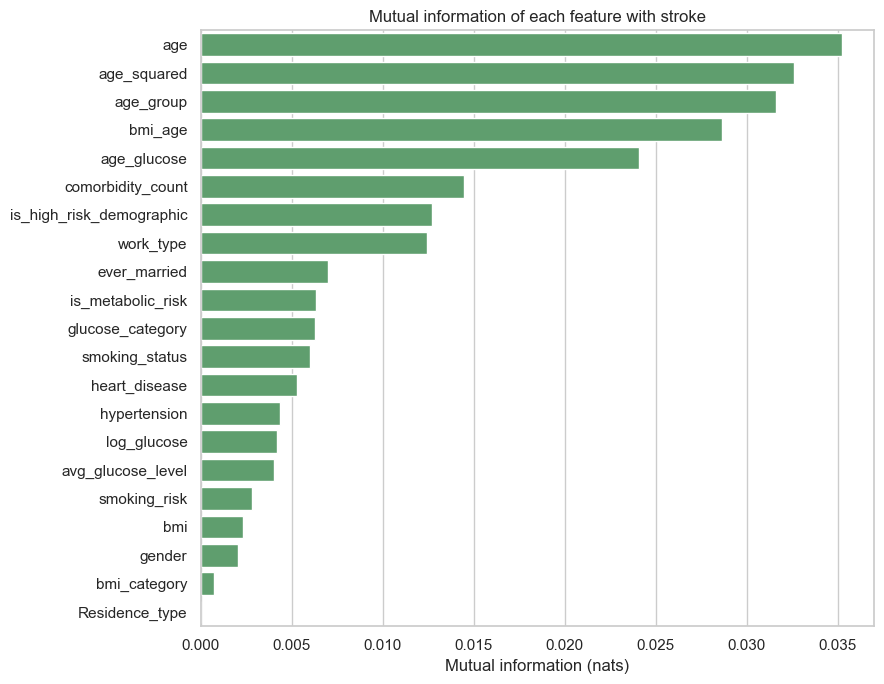

In [5]:
def encode_for_scoring(data: pd.DataFrame, target: str = "stroke") -> pd.DataFrame:
    work = data.copy()
    for col in work.columns:
        if not pd.api.types.is_numeric_dtype(work[col]):
            work[col] = work[col].astype("object").fillna("__missing__")
            work[col] = LabelEncoder().fit_transform(work[col].astype(str))
    # MI and chi2 cannot consume NaN; drop residual missing rows.
    work = work.dropna().reset_index(drop=True)
    return work


df_scored = encode_for_scoring(df_eng)
y = df_scored["stroke"].astype(int).values
X = df_scored.drop(columns=["stroke"])

# Chi-squared requires non-negative values. Shift columns that contain negatives.
X_chi = X.copy()
for col in X_chi.columns:
    col_min = X_chi[col].min()
    if col_min < 0:
        X_chi[col] = X_chi[col] - col_min

chi2_stats, chi2_pvals = chi2(X_chi.values, y)
mi_scores = mutual_info_classif(X.values, y, random_state=RANDOM_STATE)

ranking = (
    pd.DataFrame(
        {
            "feature": X.columns,
            "chi2": chi2_stats,
            "chi2_pvalue": chi2_pvals,
            "mutual_information": mi_scores,
        }
    )
    .sort_values("mutual_information", ascending=False)
    .reset_index(drop=True)
)
print(ranking.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(
    data=ranking,
    x="mutual_information",
    y="feature",
    color="#55A868",
    ax=ax,
)
ax.set_title("Mutual information of each feature with stroke")
ax.set_xlabel("Mutual information (nats)")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_feature_importance_mi.png", dpi=150, bbox_inches="tight")
plt.show()

## 4.5 Feature Selection Strategy

Feature selection is strictly a model-selection step and must therefore be fit exclusively on the training split to avoid information leakage. We carve a stratified 80/20 split from the enriched data and apply ``SelectKBest`` with a mutual-information scorer, retaining ``K = 15`` features. The selection performed here is illustrative; the final, model-specific feature set will be chosen together with hyper-parameters in Phase 2 using cross-validated pipelines.

In [6]:
K = 15

X_full = df_scored.drop(columns=["stroke"])
y_full = df_scored["stroke"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_full,
    y_full,
    test_size=0.20,
    stratify=y_full,
    random_state=RANDOM_STATE,
)

selector = SelectKBest(
    score_func=lambda X, y: mutual_info_classif(X, y, random_state=RANDOM_STATE),
    k=min(K, X_train.shape[1]),
)
selector.fit(X_train, y_train)

selected_mask = selector.get_support()
selected_features = X_train.columns[selected_mask].tolist()
selected_scores = selector.scores_[selected_mask]

selected_df = (
    pd.DataFrame({"feature": selected_features, "mi_score": selected_scores})
    .sort_values("mi_score", ascending=False)
    .reset_index(drop=True)
)
print(f"Top-{K} features selected on the training split (MI scorer):")
print(selected_df.to_string(index=False))

Top-15 features selected on the training split (MI scorer):
                 feature  mi_score
                     age  0.037615
               age_group  0.036349
                 bmi_age  0.034135
             age_squared  0.031604
             age_glucose  0.024582
            hypertension  0.011660
is_high_risk_demographic  0.011615
       comorbidity_count  0.011557
        glucose_category  0.010177
          smoking_status  0.008621
           heart_disease  0.006969
                     bmi  0.004674
            ever_married  0.004513
            smoking_risk  0.003907
             log_glucose  0.003650


## 4.6 Correlation of Engineered Features

Engineered features are prone to redundancy: ``age_squared`` is by construction close to a monotone transform of ``age``, ``log_glucose`` is a monotone transform of ``avg_glucose_level``, and the interaction terms ``age_glucose`` and ``bmi_age`` inherit most of their variance from the largest factor. Strong collinearity inflates the variance of linear-model coefficients and obscures interpretability, so we inspect a Pearson correlation matrix over the numeric feature set before committing to a final selection.

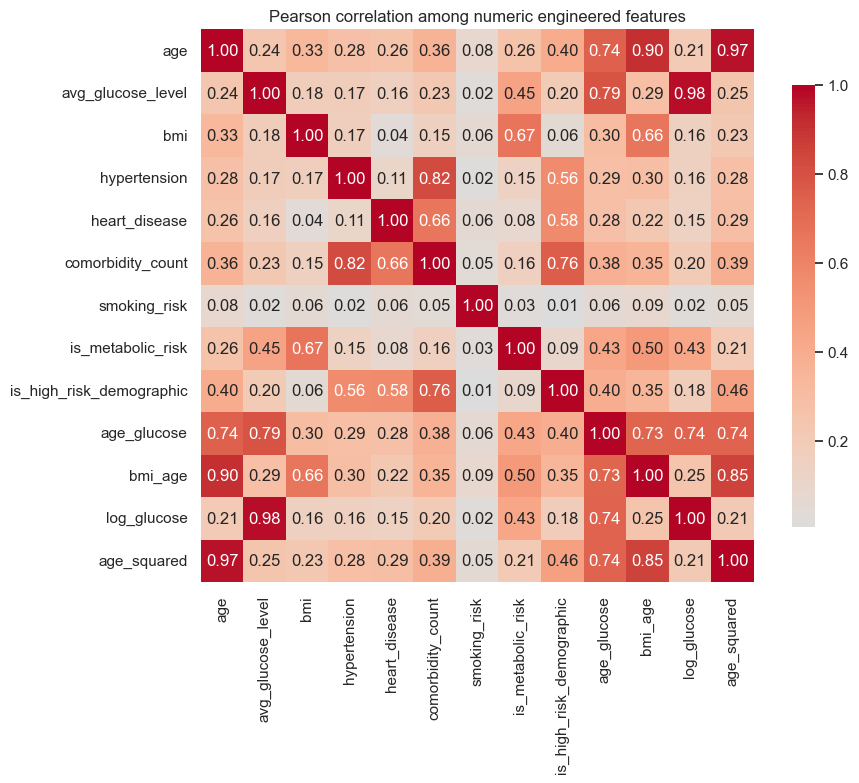

Pairs with |r| >= 0.9 (multicollinearity warning):
        feature_a   feature_b  pearson_r
              age     bmi_age   0.904142
              age age_squared   0.965451
avg_glucose_level log_glucose   0.979915


In [7]:
numeric_cols = [
    "age",
    "avg_glucose_level",
    "bmi",
    "hypertension",
    "heart_disease",
    "comorbidity_count",
    "smoking_risk",
    "is_metabolic_risk",
    "is_high_risk_demographic",
    "age_glucose",
    "bmi_age",
    "log_glucose",
    "age_squared",
]
numeric_cols = [c for c in numeric_cols if c in df_eng.columns]

corr = df_eng[numeric_cols].corr(method="pearson")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8},
    ax=ax,
)
ax.set_title("Pearson correlation among numeric engineered features")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_engineered_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

# Flag pairs with |r| >= 0.9 to warn about multicollinearity.
high_pairs = (
    corr.where(np.triu(np.ones_like(corr, dtype=bool), k=1))
    .stack()
    .rename("pearson_r")
    .reset_index()
    .rename(columns={"level_0": "feature_a", "level_1": "feature_b"})
)
high_pairs = high_pairs.loc[high_pairs["pearson_r"].abs() >= 0.9]
print("Pairs with |r| >= 0.9 (multicollinearity warning):")
print(high_pairs.to_string(index=False))

As expected, ``age`` and ``age_squared`` are near-perfectly correlated, and ``log_glucose`` tracks ``avg_glucose_level`` closely. The interaction terms ``age_glucose`` and ``bmi_age`` exhibit strong correlation with their dominant parent factor (age). For linear models we will therefore either (a) drop the redundant parent, (b) apply L2 regularisation to absorb the collinearity, or (c) replace the raw factor with the orthogonalised residual. Tree-based models are invariant to monotone transforms and can retain all features without penalty. This decision is deferred to Phase 2 where it can be benchmarked per model.

## 4.7 Final Feature Set

The enriched dataset retains every original column and appends the following twelve engineered features:

- ``age_group`` — ordinal age strata
- ``bmi_category`` — WHO BMI classes (NaN where BMI is missing)
- ``glucose_category`` — ADA glycaemic strata
- ``comorbidity_count`` — hypertension + heart_disease
- ``smoking_risk`` — ordinal smoking score
- ``is_metabolic_risk`` — binary metabolic syndrome flag
- ``is_high_risk_demographic`` — older adult with comorbidity
- ``age_glucose`` — multiplicative risk interaction
- ``bmi_age`` — multiplicative risk interaction
- ``log_glucose`` — variance-stabilised glucose
- ``age_squared`` — polynomial curvature in age

We persist the enriched frame in raw, unscaled, unencoded form so that Phase 2's ``ColumnTransformer`` pipeline can own imputation, scaling and categorical encoding end-to-end.

In [8]:
engineered_out = OUTPUTS_DIR / "stroke_engineered.csv"
df_eng.to_csv(engineered_out, index=False)
print(f"Wrote enriched dataset → {engineered_out}")
print(f"Rows: {df_eng.shape[0]}, Columns: {df_eng.shape[1]}")

Wrote enriched dataset → C:\Users\donat\Desktop\Markie\outputs\stroke_engineered.csv
Rows: 5109, Columns: 22


## 4.8 Discussion

The engineered feature battery is a direct operationalisation of well-established stroke risk factors. Age is the single strongest non-modifiable predictor of ischaemic stroke in every major cohort study, and its effect is markedly non-linear: risk approximately doubles every decade after 55. Our ``age_group``, ``age_squared`` and ``age_glucose`` features collectively allow a linear model to express this curvature and its interaction with metabolic state. Hypertension and heart disease are the two dominant modifiable factors; we aggregate them into ``comorbidity_count`` and ``is_high_risk_demographic``, which aligns with how clinicians reason about cumulative cardiovascular burden rather than about individual diagnoses in isolation. Glycaemic dysregulation is captured both categorically (``glucose_category`` at ADA thresholds) and continuously (``log_glucose``), reflecting the fact that the relationship between glucose and stroke risk has both a threshold component (diagnosis of diabetes) and a dose-response component. Obesity is encoded through WHO BMI classes and the composite ``is_metabolic_risk`` flag, which together mirror the metabolic syndrome construct used in clinical screening. Finally, the ordinal ``smoking_risk`` score respects the known dose-response between lifetime tobacco exposure and cerebrovascular events while preserving ``Unknown`` cases at an uninformative midpoint rather than discarding them.

The trade-offs are worth naming explicitly. First, every engineered feature increases the dimensionality of the representation and, if used naïvely, can exacerbate the curse of dimensionality given the 4.9 % positive rate and 5,109 rows. Second, several engineered features are near-collinear with their parents (for example, ``age_squared`` with ``age``), which inflates the variance of logistic-regression coefficients and complicates interpretation; L2 regularisation or orthogonalisation will be necessary for linear models. Third, hand-crafted features encode assumptions drawn from the medical literature, and those assumptions are themselves empirical claims; if the training distribution departs from the populations on which those thresholds were derived, the features can carry bias forward into the model. Mitigations include validating every engineered feature against the target on held-out data (as we did with the mutual-information ranking), monitoring subgroup performance in Phase 3, and preferring monotone constraints and regularisation to ad hoc bin boundaries when possible. The final ranked importance table and the correlation diagnostics in this notebook provide the quantitative justification for keeping or dropping each feature in the modelling phase.